In [14]:
#Descarga de librerias necesarias

import pandas as pd
import numpy as np

In [15]:
#Leer el archivo y visualizarlo

df = pd.read_csv("Dataset_Pruebas.csv")

df.head()

,user_id,age,country,events_last_30d,purchases_last_30d,total_spend_last_30d,churned
0,1,40,MX,46,3,24.461384,0
1,2,33,CL,57,4,39.683693,0
2,3,42,MX,52,6,75.392918,0
3,4,53,CL,41,7,181.208986,0
4,5,32,CL,45,4,31.608351,0


##### Preparación de datos

Antes del entrenamiento del modelo se aplicaron transformaciones derivadas del análisis exploratorio:

* eliminación de edades inválidas (age < 0 o age > 100)
* exclusión de actividad extrema (events_last_30d > 10.000)
* eliminación de valores negativos en gasto
* remoción de registros duplicados

Aunque durante el EDA se consideró preservar ciertos outliers mediante variables derivadas (por ejemplo refunds o actividad sospechosa), para este baseline inicial se priorizó un pipeline simple y robusto debido al tamaño reducido del dataset y al objetivo exploratorio del ejercicio.

La variable categórica country fue transformada mediante LabelEncoder.

Adicionalmente, se aplicó StandardScaler únicamente para Logistic Regression debido a la sensibilidad de modelos lineales a diferencias de escala entre variables.
Random Forest no requiere normalización por estar basado en árboles de decisión.

Finalmente, se utilizó class_weight='balanced' para compensar el desbalance de clases observado (~90/10).

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Copia del dataset original
df_model = df.copy()

# Limpieza de datos
# Eliminar edades inválidas
df_model = df_model[
    (df_model["age"] >= 0) &
    (df_model["age"] <= 100)
]

# Eliminar actividad extrema
df_model = df_model[
    df_model["events_last_30d"] <= 10000
]

# Eliminar spend negativo
df_model = df_model[
    df_model["total_spend_last_30d"] >= 0
]

# Eliminar duplicados
df_model = df_model.drop_duplicates()

In [17]:
# Features y target

features = [
    "age",
    "country",
    "events_last_30d",
    "purchases_last_30d",
    "total_spend_last_30d"
]

target = "churned"

X = df_model[features]
y = df_model[target]

In [18]:
# Encoding variable categórica
le = LabelEncoder()

X["country"] = le.fit_transform(X["country"])

C:\Users\dshar\AppData\Local\Temp\ipykernel_10816\1426214098.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["country"] = le.fit_transform(X["country"])


In [19]:
# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [20]:
# Escalamiento (solo Logistic Regression)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
# Verificación
print("Shape original:", df.shape)
print("Shape limpio:", df_model.shape)

print("\nDistribución target:")
print(y.value_counts(normalize=True))

Shape original: (2020, 7)
Shape limpio: (1991, 7)

Distribución target:
churned
0    0.903566
1    0.096434
Name: proportion, dtype: float64


##### Entrenamiento del modelo ML

Y aquí vamos a hacerlo de forma estratégica:

Logistic Regression (baseline interpretable)
Random Forest (modelo no lineal)
Comparación
Métricas
Feature importance
Interpretación de resultados

Paso 1 — Logistic Regression

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score
)

# =========================================
# Modelo Logistic Regression
# =========================================

log_model = LogisticRegression(
    class_weight='balanced',
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

# =========================================
# Predicciones
# =========================================

y_pred_log = log_model.predict(X_test_scaled)

y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]

# =========================================
# Métricas
# =========================================

f1_log = f1_score(y_test, y_pred_log)

auc_log = roc_auc_score(y_test, y_prob_log)

print("F1 Score:", round(f1_log,4))
print("ROC AUC:", round(auc_log,4))

print("\nClassification Report")
print(classification_report(y_test, y_pred_log))

F1 Score: 0.1674
ROC AUC: 0.4999

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.53      0.67       361
           1       0.10      0.50      0.17        38

    accuracy                           0.53       399
   macro avg       0.51      0.51      0.42       399
weighted avg       0.83      0.53      0.62       399



Paso 2 — Random Forest

In [23]:
from sklearn.ensemble import RandomForestClassifier

# =========================================
# Modelo Random Forest
# =========================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

# =========================================
# Predicciones
# =========================================

y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

# =========================================
# Métricas
# =========================================

f1_rf = f1_score(y_test, y_pred_rf)

auc_rf = roc_auc_score(y_test, y_prob_rf)

print("F1 Score:", round(f1_rf,4))
print("ROC AUC:", round(auc_rf,4))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

F1 Score: 0.0698
ROC AUC: 0.5139

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       361
           1       0.06      0.08      0.07        38

    accuracy                           0.80       399
   macro avg       0.48      0.48      0.48       399
weighted avg       0.82      0.80      0.81       399



In [24]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "F1 Score": [f1_log, f1_rf],
    "ROC AUC": [auc_log, auc_rf]
})

results

,Model,F1 Score,ROC AUC
0,Logistic Regression,0.167401,0.499854
1,Random Forest,0.069767,0.513923


In [25]:
log_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": log_model.coef_[0]
})

log_importance = log_importance.sort_values(
    by="Coefficient",
    ascending=False
)

log_importance

,Feature,Coefficient
2,events_last_30d,0.162427
4,total_spend_last_30d,0.097413
3,purchases_last_30d,0.072780
0,age,0.053498
1,country,0.023446


In [26]:
rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

rf_importance

,Feature,Importance
4,total_spend_last_30d,0.306237
0,age,0.241176
2,events_last_30d,0.229243
3,purchases_last_30d,0.165510
1,country,0.057834


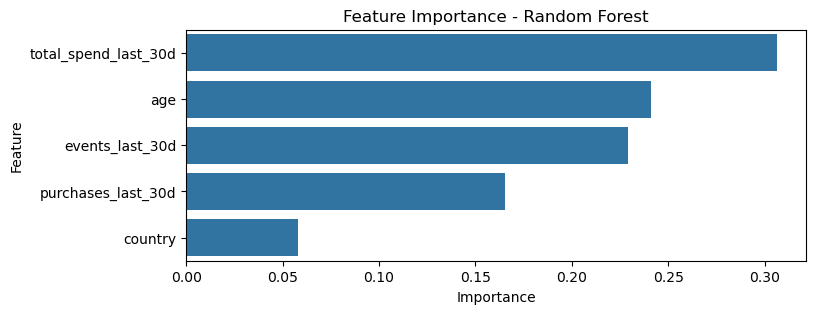

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,3))

sns.barplot(
    data=rf_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Random Forest")

plt.show()